In [1]:
from langgraph.graph import StateGraph , START,END
from typing import TypedDict , Literal
from pydantic import BaseModel,Field
from dotenv import load_dotenv
from langchain_groq import ChatGroq

In [2]:
!pip install langchain-groq

In [3]:
!pip install LangGraph


In [4]:
from dotenv import load_dotenv
load_dotenv()


True

In [5]:
import os
model = ChatGroq(api_key=os.getenv("GROQ_API_KEY")
                 ,temperature=0.0,
                 model = "openai/gpt-oss-120b")

In [6]:
class query(BaseModel):
    query_type: Literal["student policies",'hostel rules','placement guidelines','admission_faq','scholarship details','not classified']


In [7]:
structured_model= model.with_structured_output(query)

In [8]:
promt= "what are the admission rules"
ans = structured_model.invoke(promt)
print(ans)

query_type='admission_faq'


In [9]:
class review_state(TypedDict):
    response: str
    query_type : Literal["student policies",'hostel rules','placement guidelines','admission_faq','scholarship details','not classified']
    query : str


In [10]:
graph = StateGraph(review_state)


In [11]:
def check_query_type(state: review_state)->Literal["student policies",'hostel rules','placement guidelines','admission_faq','scholarship details','not classified']:
     query=state['query']
     query_typed= structured_model.invoke(query)
     print(query_typed)
     return {'query_type':query_typed.query_type }





In [12]:
def not_classified(state: review_state):
    pass

In [13]:
def student_policies(state: review_state):
     pass


In [14]:
def scholarship(state: review_state):
    pass

In [15]:
def admission_faq(state: review_state):
    pass

In [16]:
def hostel_rules(state: review_state):
    pass

In [17]:
def placement_guidelines(state: review_state):
    pass


In [18]:

graph.add_node('hostel rules',hostel_rules)
graph.add_node('placement guidelines',placement_guidelines)

graph.add_node('admission faq',admission_faq)
graph.add_node('scholarship',scholarship)


In [19]:
graph.add_node('check query type',check_query_type)
graph.add_node('student policies',student_policies)
graph.add_node('not classified' ,not_classified)

In [20]:

def route_query(state: review_state):
    return state["query_type"]


In [21]:
graph.add_edge(START,'check query type')
graph.add_conditional_edges(
    "check query type",
    route_query,
    {
     "student policies":"student policies"
    ,'hostel rules':'hostel rules'
    ,'placement guidelines':'placement guidelines'
    ,'admission_faq':'admission faq',
    'scholarship details':'scholarship',
    'not_classified':'not classified'
    }
)


In [22]:
graph.add_edge('student policies',END)
graph.add_edge('hostel rules',END)
graph.add_edge('placement guidelines',END)
graph.add_edge('admission faq',END)
graph.add_edge('scholarship',END)
graph.add_edge('not classified',END)


In [23]:
graph.add_edge(START,"check query type")

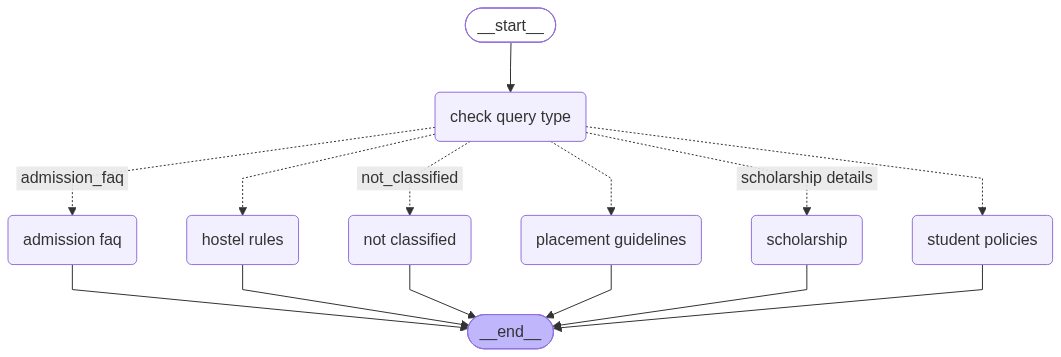

In [24]:
graph.compile()

In [25]:
workflow = graph.compile()

In [26]:

from RAG.retriever import rag_chain



C:\Users\Archi\Desktop\student_assistant\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8934.02it/s]


In [27]:
prompt = "how is iet davv "

In [28]:
response = workflow.invoke(
    {"query": "how are the placments"}
)

query_type='placement guidelines'


In [29]:
print(response)

{'query_type': 'placement guidelines', 'query': 'how are the placments'}
